🔍 Optimizando modelos para maximizar AUC-ROC...

🔹 Entrenando: Regresión Logística
   ✅ AUC-ROC: 0.656 | AUC-PR: 0.510 | F1: 0.478
   📊 Recall: 51.6% | Precisión: 44.4%

🔹 Entrenando: SVM
   ✅ AUC-ROC: 0.587 | AUC-PR: 0.409 | F1: 0.300
   📊 Recall: 29.0% | Precisión: 31.0%

🔹 Entrenando: KNN
   ✅ AUC-ROC: 0.516 | AUC-PR: 0.361 | F1: 0.424
   📊 Recall: 58.1% | Precisión: 33.3%

🔹 Entrenando: Random Forest
   ✅ AUC-ROC: 0.620 | AUC-PR: 0.410 | F1: 0.377
   📊 Recall: 32.3% | Precisión: 45.5%

🔹 Entrenando: Gradient Boosting
   ✅ AUC-ROC: 0.654 | AUC-PR: 0.450 | F1: 0.340
   📊 Recall: 29.0% | Precisión: 40.9%

🔹 Entrenando: AdaBoost
   ✅ AUC-ROC: 0.612 | AUC-PR: 0.439 | F1: 0.459
   📊 Recall: 45.2% | Precisión: 46.7%

🔹 Entrenando: Extra Trees
   ✅ AUC-ROC: 0.606 | AUC-PR: 0.414 | F1: 0.326
   📊 Recall: 22.6% | Precisión: 58.3%

🔹 Entrenando: XGBoost
   ✅ AUC-ROC: 0.640 | AUC-PR: 0.511 | F1: 0.433
   📊 Recall: 41.9% | Precisión: 44.8%


🏆 === RESUMEN FINAL (ordenado por AUC-ROC) ===
      

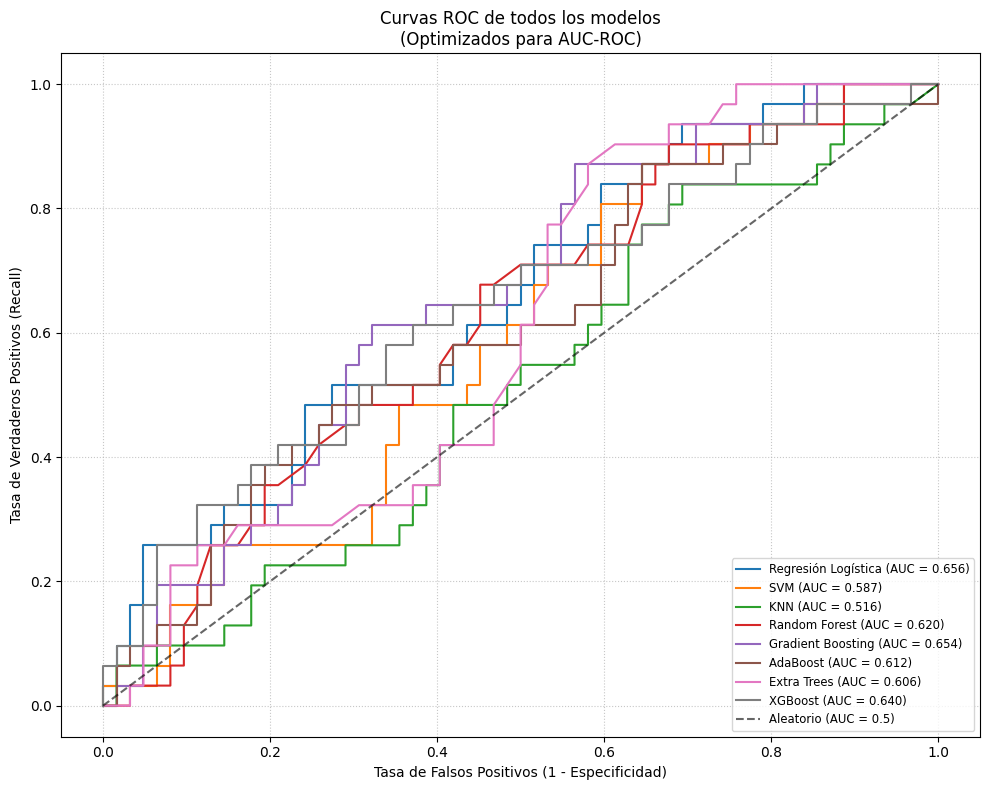

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score
)
from sklearn.metrics import recall_score, precision_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")
from imblearn.over_sampling import RandomOverSampler, ADASYN, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek

df = pd.read_csv("data.csv")
df.head()
X = df.drop('survival_3yr', axis=1)
y = df['survival_3yr']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)

# -------------------------------------------------
# 2. CONFIGURACIÓN DE MODELOS Y ESPACIOS DE HIPERPARÁMETROS
# -------------------------------------------------
pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

model_configs = {
    "Regresión Logística": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))]),
        "params": {"clf__C": [0.01, 0.1, 1, 10, 100], "clf__solver": ['liblinear', 'saga']}
    },
    "SVM": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", SVC(class_weight='balanced', probability=True, random_state=42))]),
        "params": {"clf__C": [0.1, 1, 10], "clf__gamma": ['scale', 'auto', 0.001, 0.01], "clf__kernel": ['rbf', 'linear']}
    },
    "KNN": {
        "pipeline": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        "params": {"clf__n_neighbors": [3, 5, 7, 9, 11], "clf__weights": ['uniform', 'distance'], "clf__metric": ['euclidean', 'manhattan']}
    },
    "Random Forest": {
        "pipeline": Pipeline([("clf", RandomForestClassifier(class_weight='balanced', random_state=42))]),
        "params": {"clf__n_estimators": [50, 100, 200], "clf__max_depth": [3, 5, 7, None], "clf__min_samples_split": [2, 5, 10]}
    },
    "Gradient Boosting": {
        "pipeline": Pipeline([("clf", GradientBoostingClassifier(random_state=42))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__learning_rate": [0.01, 0.1, 0.2],
            "clf__max_depth": [3, 5, 7],
            "clf__subsample": [0.8, 1.0]
        }
    },
    "AdaBoost": {
        "pipeline": Pipeline([("clf", AdaBoostClassifier(random_state=42))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0]
        }
    },
    "Extra Trees": {
        "pipeline": Pipeline([("clf", ExtraTreesClassifier(class_weight='balanced', random_state=42))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_depth": [3, 5, 7, None],
            "clf__min_samples_split": [2, 5, 10]
        }
    },
    "XGBoost": {
        "pipeline": Pipeline([("clf", XGBClassifier(
            scale_pos_weight=pos_weight,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        ))]),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_depth": [3, 5, 7],
            "clf__learning_rate": [0.01, 0.1, 0.2],
            "clf__subsample": [0.8, 1.0],
            "clf__colsample_bytree": [0.8, 1.0]
        }
    }
}

# -------------------------------------------------
# 3. ENTRENAMIENTO Y EVALUACIÓN (optimizado para AUC-ROC)
# -------------------------------------------------
results_auc = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("🔍 Optimizando modelos para maximizar AUC-ROC...\n")

for name, config in model_configs.items():
    print(f"🔹 Entrenando: {name}")
    
    # Búsqueda de hiperparámetros usando AUC-ROC
    search = RandomizedSearchCV(
        config["pipeline"],
        config["params"],
        n_iter=20,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42
    )
    
    try:
        search.fit(X_train, y_train)
    except Exception as e:
        print(f"   ❌ Error: {e}\n")
        continue
    
    best_model = search.best_estimator_
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = best_model.predict(X_test)  # umbral estándar (0.5)
    
    # Métricas
    auc_roc = roc_auc_score(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    vpn = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    results_auc.append({
        "Modelo": name,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "F1-score": f1,
        "Recall": rec,
        "Precisión": prec,
        "VPN": vpn,
        "y_proba": y_proba,
        "y_pred": y_pred,
        "best_params": search.best_params_
    })
    
    print(f"   ✅ AUC-ROC: {auc_roc:.3f} | AUC-PR: {auc_pr:.3f} | F1: {f1:.3f}")
    print(f"   📊 Recall: {rec:.1%} | Precisión: {prec:.1%}\n")

# -------------------------------------------------
# 4. RESUMEN FINAL (ordenado por AUC-ROC)
# -------------------------------------------------
if results_auc:
    summary_auc = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_proba', 'y_pred', 'best_params']} for r in results_auc])
    summary_auc = summary_auc.sort_values('AUC-ROC', ascending=False)
    
    print("\n🏆 === RESUMEN FINAL (ordenado por AUC-ROC) ===")
    print(summary_auc.to_string(index=False, float_format='%.3f'))
    
    # Guardar
    summary_auc.to_csv("resultados_modelos_auc_roc.csv", index=False)

# -------------------------------------------------
# 5. VISUALIZACIÓN: CURVAS ROC DE TODOS LOS MODELOS
# -------------------------------------------------
plt.figure(figsize=(10, 8))

for r in results_auc:
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    plt.plot(fpr, tpr, label=f'{r["Modelo"]} (AUC = {r["AUC-ROC"]:.3f})')

# Línea diagonal (azar)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curvas ROC de todos los modelos\n(Optimizados para AUC-ROC)')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("curvas_roc_todos_modelos.png", dpi=200)
plt.show()